In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Global_Oral.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted")
print(os.listdir(extract_path))

Dataset Extracted
['train', 'valid', 'test']


In [30]:
import os
import json
import joblib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Paths
train_dir = "/content/data/train"
valid_dir = "/content/data/valid"
test_dir  = "/content/data/test"

SAVE_DIR = "/content/drive/MyDrive/Ensemble_Final"
os.makedirs(SAVE_DIR, exist_ok=True)

Device: cuda


In [31]:
IMG_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
valid_data = datasets.ImageFolder(valid_dir, transform=transform)
test_data  = datasets.ImageFolder(test_dir,  transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_data.classes)

Classes: ['Cancer', 'Control']


In [36]:
# ---------- ResNet ----------
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

ckpt = torch.load("/content/drive/MyDrive/RESNET_final.pth", map_location=device)

# If saved as full checkpoint OR direct state_dict
if "model" in ckpt:
    resnet.load_state_dict(ckpt["model"])
else:
    resnet.load_state_dict(ckpt)

resnet.to(device).eval()


# ---------- EfficientNet ----------
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, 2)

ckpt = torch.load("/content/drive/MyDrive/EfficientNet_Final.pth", map_location=device)

if "model" in ckpt:
    efficientnet.load_state_dict(ckpt["model"])
else:
    efficientnet.load_state_dict(ckpt)

efficientnet.to(device).eval()


# ---------- DenseNet ----------
densenet = models.densenet121(weights=None)
densenet.classifier = nn.Linear(densenet.classifier.in_features, 2)

ckpt = torch.load("/content/drive/MyDrive/DenseNet_Final.pth", map_location=device)

if "model" in ckpt:
    densenet.load_state_dict(ckpt["model"])
else:
    densenet.load_state_dict(ckpt)

densenet.to(device).eval()

print("All Models Loaded Successfully ✅")

All Models Loaded Successfully ✅


In [37]:
import torch.nn.functional as F

def get_probs(model, loader):
    probs = []
    labels = []

    model.eval()
    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)

            outputs = model(images)
            p = F.softmax(outputs, dim=1)[:, 1]   # class-1 probability

            probs.extend(p.cpu().numpy())
            labels.extend(target.numpy())

    return np.array(probs), np.array(labels)

print("Function Ready")

Function Ready


In [38]:
# Get probabilities from all 3 models
res_val, y_val = get_probs(resnet, valid_loader)
eff_val, _     = get_probs(efficientnet, valid_loader)
den_val, _     = get_probs(densenet, valid_loader)

# Meta dataset
X_meta = np.column_stack((res_val, eff_val, den_val))
y_meta = y_val

print("X_meta Shape:", X_meta.shape)
print("y_meta Shape:", y_meta.shape)
print(X_meta[:5])

X_meta Shape: (414, 3)
y_meta Shape: (414,)
[[9.0541983e-01 1.7217408e-01 1.0518157e-02]
 [7.3205119e-01 1.0862748e-04 9.6228684e-04]
 [1.8928161e-01 2.4152548e-06 2.8360400e-06]
 [1.2675950e-01 1.0559402e-03 2.9767025e-04]
 [4.3208411e-01 2.2788368e-05 5.8189366e-04]]


In [39]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression()

meta_model.fit(X_meta, y_meta)

joblib.dump(meta_model, f"{SAVE_DIR}/meta_lr.pkl")

print("Meta Model Trained & Saved")

Meta Model Trained & Saved


In [40]:
# Test probabilities
res_test, y_test = get_probs(resnet, test_loader)
eff_test, _      = get_probs(efficientnet, test_loader)
den_test, _      = get_probs(densenet, test_loader)

# Meta test data
X_test_meta = np.column_stack((res_test, eff_test, den_test))

# Final prediction
y_pred = meta_model.predict(X_test_meta)
y_prob = meta_model.predict_proba(X_test_meta)[:, 1]

print("Test Meta Shape:", X_test_meta.shape)

Test Meta Shape: (414, 3)


Accuracy    : 0.9782608695652174
Precision   : 0.9759615384615384
Recall      : 0.9806763285024155
F1 Score    : 0.9783132530120482
Specificity : 0.9758454106280193


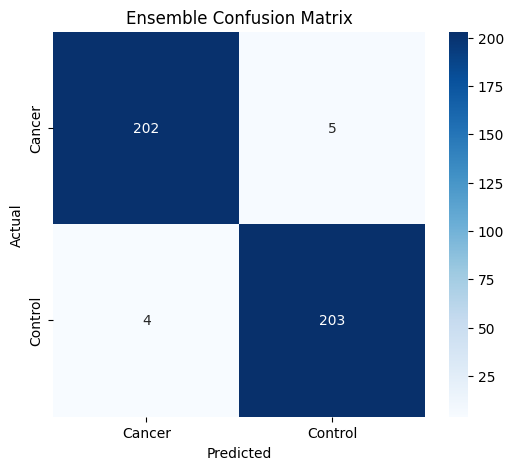

In [41]:
import seaborn as sns

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
spec = tn / (tn + fp)

print("Accuracy    :", acc)
print("Precision   :", prec)
print("Recall      :", rec)
print("F1 Score    :", f1)
print("Specificity :", spec)

# Save metrics
results = {
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1_score": float(f1),
    "specificity": float(spec)
}

with open(f"{SAVE_DIR}/ensemble_metrics.json", "w") as f:
    json.dump(results, f, indent=4)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cancer","Control"],
            yticklabels=["Cancer","Control"])
plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

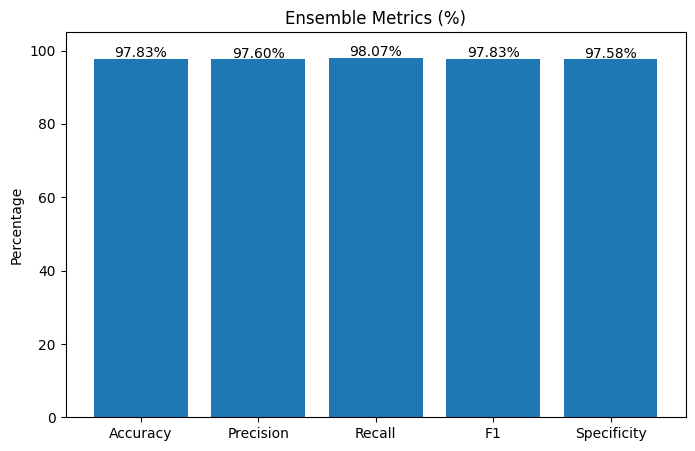

Everything Saved In: /content/drive/MyDrive/Ensemble_Final


In [42]:
# Metrics bar graph
names = ["Accuracy", "Precision", "Recall", "F1", "Specificity"]
values = [acc*100, prec*100, rec*100, f1*100, spec*100]

plt.figure(figsize=(8,5))
bars = plt.bar(names, values)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val+0.5, f"{val:.2f}%", ha="center")

plt.ylim(0, 105)
plt.title("Ensemble Metrics (%)")
plt.ylabel("Percentage")
plt.savefig(f"{SAVE_DIR}/metrics_bargraph.png", dpi=300, bbox_inches="tight")
plt.show()

# Save backup config
backup = {
    "models": ["ResNet", "EfficientNet", "DenseNet"],
    "meta_learner": "LogisticRegression",
    "test_samples": int(len(y_test)),
    "accuracy": float(acc)
}

with open(f"{SAVE_DIR}/backup_config.json", "w") as f:
    json.dump(backup, f, indent=4)

print("Everything Saved In:", SAVE_DIR)

In [43]:
import joblib
import json

SAVE_DIR = "/content/drive/MyDrive/Ensemble_Final"

# Load meta model
meta_model = joblib.load(f"{SAVE_DIR}/meta_lr.pkl")

# Load metrics
with open(f"{SAVE_DIR}/ensemble_metrics.json", "r") as f:
    metrics = json.load(f)

# Load config
with open(f"{SAVE_DIR}/backup_config.json", "r") as f:
    backup = json.load(f)

print("Recovered Successfully")
print("Meta Learner:", backup["meta_learner"])
print("Accuracy:", metrics["accuracy"])

Recovered Successfully
Meta Learner: LogisticRegression
Accuracy: 0.9782608695652174


AUC Score: 0.9986580783682233


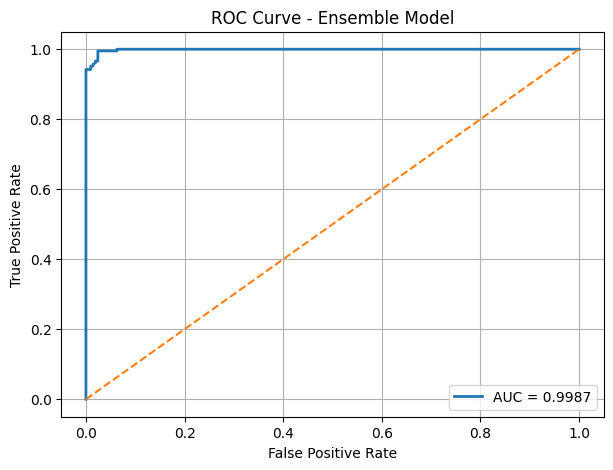

ROC Curve Saved In: /content/drive/MyDrive/Ensemble_Final


In [44]:
from sklearn.metrics import roc_curve, auc

# ROC data
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot ROC
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ensemble Model")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig(f"{SAVE_DIR}/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Save AUC in metrics json
results["auc"] = float(roc_auc)

with open(f"{SAVE_DIR}/ensemble_metrics.json", "w") as f:
    json.dump(results, f, indent=4)

print("ROC Curve Saved In:", SAVE_DIR)

Device: cuda


Saving 262.jpeg to 262 (1).jpeg


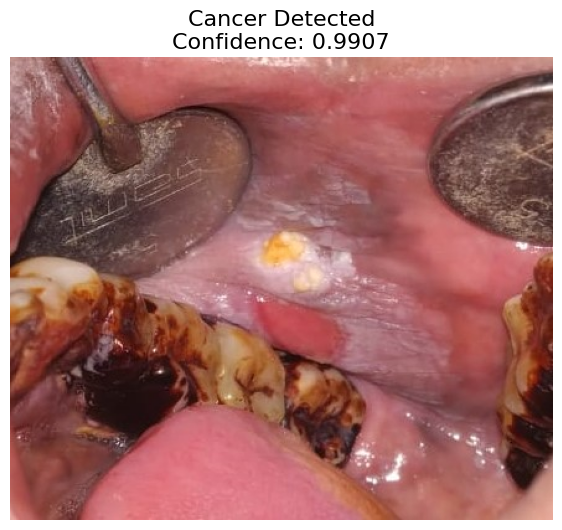

=========== BASE MODEL SCORES ===========
ResNet Cancer   : 0.9966
ResNet Control  : 0.0034
-----------------------------------------
EffNet Cancer   : 1.0
EffNet Control  : 0.0
-----------------------------------------
Dense Cancer    : 1.0
Dense Control   : 0.0
Final Result : Cancer Detected
Confidence   : 0.9907


In [61]:
# =========================================================
# COMPLETE FINAL STACK MODEL TEST CODE (FIXED)
# =========================================================

import torch, joblib, numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from torchvision import transforms, models

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------- UPLOAD IMAGE ----------------
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ---------------- LOAD RESNET ----------------
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

ckpt = torch.load("/content/drive/MyDrive/RESNET_final.pth", map_location=device)
resnet.load_state_dict(ckpt)   # direct loading

resnet.to(device).eval()

# ---------------- LOAD EFFICIENTNET ----------------
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 2
)

ckpt = torch.load("/content/drive/MyDrive/EfficientNet_Final.pth", map_location=device)
efficientnet.load_state_dict(ckpt["model"])

efficientnet.to(device).eval()

# ---------------- LOAD DENSENET ----------------
densenet = models.densenet121(weights=None)
densenet.classifier = nn.Linear(
    densenet.classifier.in_features, 2
)

ckpt = torch.load("/content/drive/MyDrive/DenseNet_Final.pth", map_location=device)
densenet.load_state_dict(ckpt["model"])

densenet.to(device).eval()

# ---------------- LOAD META MODEL ----------------
meta_model = joblib.load("/content/drive/MyDrive/Ensemble_Final/meta_lr.pkl")

# ---------------- LOAD IMAGE ----------------
img = Image.open(img_path).convert("RGB")
show_img = img.copy()

x = transform(img).unsqueeze(0).to(device)

# ---------------- BASE MODEL PREDICTIONS ----------------
with torch.no_grad():
    r = F.softmax(resnet(x), dim=1).cpu().numpy()[0]
    e = F.softmax(efficientnet(x), dim=1).cpu().numpy()[0]
    d = F.softmax(densenet(x), dim=1).cpu().numpy()[0]

X_meta = np.array([[r[1], e[1], d[1]]])

# ---------------- FINAL STACK PREDICTION ----------------
pred = meta_model.predict(X_meta)[0]
probs = meta_model.predict_proba(X_meta)[0]

if pred == 0:
    label = "Cancer Detected"
    confidence = probs[0]
else:
    label = "No Cancer"
    confidence = probs[1]

# ---------------- SHOW RESULT ----------------
plt.figure(figsize=(7,7))
plt.imshow(show_img)
plt.axis("off")
plt.title(f"{label}\nConfidence: {confidence:.4f}", fontsize=16)
plt.show()

# ---------------- PRINT DETAILS ----------------
print("=========== BASE MODEL SCORES ===========")
print("ResNet Cancer   :", round(float(r[0]),4))
print("ResNet Control  :", round(float(r[1]),4))
print("-----------------------------------------")
print("EffNet Cancer   :", round(float(e[0]),4))
print("EffNet Control  :", round(float(e[1]),4))
print("-----------------------------------------")
print("Dense Cancer    :", round(float(d[0]),4))
print("Dense Control   :", round(float(d[1]),4))
print("=========================================")
print("Final Result :", label)
print("Confidence   :", round(float(confidence),4))
print("=========================================")

Device: cuda


Saving 086_aug_792.jpeg to 086_aug_792.jpeg


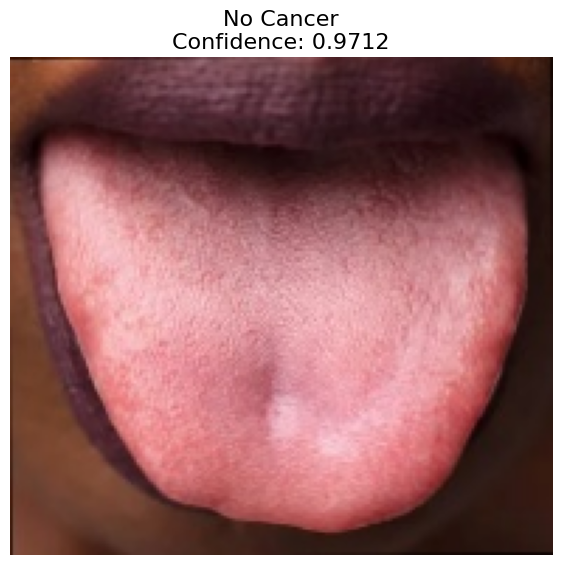

=========== BASE MODEL SCORES ===========
ResNet Cancer   : 0.0
ResNet Control  : 1.0
-----------------------------------------
EffNet Cancer   : 0.0
EffNet Control  : 1.0
-----------------------------------------
Dense Cancer    : 0.0074
Dense Control   : 0.9926
Final Result : No Cancer
Confidence   : 0.9712


In [54]:
# =========================================================
# COMPLETE FINAL STACK MODEL TEST CODE (FIXED)
# =========================================================

import torch, joblib, numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from torchvision import transforms, models

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------- UPLOAD IMAGE ----------------
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# ---------------- LOAD RESNET ----------------
resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

ckpt = torch.load("/content/drive/MyDrive/RESNET_final.pth", map_location=device)
resnet.load_state_dict(ckpt)   # direct loading

resnet.to(device).eval()

# ---------------- LOAD EFFICIENTNET ----------------
efficientnet = models.efficientnet_b0(weights=None)
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 2
)

ckpt = torch.load("/content/drive/MyDrive/EfficientNet_Final.pth", map_location=device)
efficientnet.load_state_dict(ckpt["model"])

efficientnet.to(device).eval()

# ---------------- LOAD DENSENET ----------------
densenet = models.densenet121(weights=None)
densenet.classifier = nn.Linear(
    densenet.classifier.in_features, 2
)

ckpt = torch.load("/content/drive/MyDrive/DenseNet_Final.pth", map_location=device)
densenet.load_state_dict(ckpt["model"])

densenet.to(device).eval()

# ---------------- LOAD META MODEL ----------------
meta_model = joblib.load("/content/drive/MyDrive/Ensemble_Final/meta_lr.pkl")

# ---------------- LOAD IMAGE ----------------
img = Image.open(img_path).convert("RGB")
show_img = img.copy()

x = transform(img).unsqueeze(0).to(device)

# ---------------- BASE MODEL PREDICTIONS ----------------
with torch.no_grad():
    r = F.softmax(resnet(x), dim=1).cpu().numpy()[0]
    e = F.softmax(efficientnet(x), dim=1).cpu().numpy()[0]
    d = F.softmax(densenet(x), dim=1).cpu().numpy()[0]

X_meta = np.array([[r[1], e[1], d[1]]])

# ---------------- FINAL STACK PREDICTION ----------------
pred = meta_model.predict(X_meta)[0]
probs = meta_model.predict_proba(X_meta)[0]

if pred == 0:
    label = "Cancer Detected"
    confidence = probs[0]
else:
    label = "No Cancer"
    confidence = probs[1]

# ---------------- SHOW RESULT ----------------
plt.figure(figsize=(7,7))
plt.imshow(show_img)
plt.axis("off")
plt.title(f"{label}\nConfidence: {confidence:.4f}", fontsize=16)
plt.show()

# ---------------- PRINT DETAILS ----------------
print("=========== BASE MODEL SCORES ===========")
print("ResNet Cancer   :", round(float(r[0]),4))
print("ResNet Control  :", round(float(r[1]),4))
print("-----------------------------------------")
print("EffNet Cancer   :", round(float(e[0]),4))
print("EffNet Control  :", round(float(e[1]),4))
print("-----------------------------------------")
print("Dense Cancer    :", round(float(d[0]),4))
print("Dense Control   :", round(float(d[1]),4))
print("=========================================")
print("Final Result :", label)
print("Confidence   :", round(float(confidence),4))
print("=========================================")